# Model Right-Sizing for Inference: DistilBERT vs Quantized DistilBERT

I wanted to understand a common assumption in ML deployment: smaller models should be faster and more efficient.

But this is not always true in real systems. A model can be smaller in size but still not show a proportional improvement in latency or throughput because inference performance also depends on runtime behavior, hardware support, batching, and execution overhead.

In this experiment, I compare an original DistilBERT model with a dynamically quantized DistilBERT model on SST-2 sentiment classification.

I measure:
- Accuracy
- Model size
- Latency per sample
- Throughput

My hypothesis is that quantization will reduce model size while keeping accuracy close to the original model. However, latency may not improve in the same proportion, which would show why model right-sizing requires real benchmarking instead of relying only on model size or parameter count.

The goal is to understand when quantization is actually useful for inference deployment.

In this experiment i will be testing : How the same NLP inference task behaves before and after quantization.

In [1]:
!pip install transformers datasets evaluate accelerate -q

In [2]:
import torch
import time
import os
import tempfile
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from sklearn.metrics import accuracy_score

In [4]:
dataset = load_dataset("nyu-mll/glue", "sst2")

test_data = dataset["validation"].select(range(500))

texts = test_data["sentence"]
labels = test_data["label"]

len(texts), texts[0], labels[0]

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

(500, "it 's a charming and often affecting journey . ", 1)

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

In [6]:
dataset["validation"][0]

{'sentence': "it 's a charming and often affecting journey . ",
 'label': 1,
 'idx': 0}

In [7]:
dataset["validation"].column_names

['sentence', 'label', 'idx']

In [8]:
#testing with 500 samples
test_data = dataset["validation"].select(range(500))

texts = test_data["sentence"]
labels = test_data["label"]

print(len(texts))
print(texts[0])
print(labels[0])

500
it 's a charming and often affecting journey . 
1


In [9]:
#loading original DistilBERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_fp32 = AutoModelForSequenceClassification.from_pretrained(model_name)

model_fp32.eval()

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [10]:
#Testing one sample with the original model
sample_text = texts[0]

inputs = tokenizer(
    sample_text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

with torch.no_grad():
    outputs = model_fp32(**inputs)

pred = torch.argmax(outputs.logits, dim=1).item()

print("Text:", sample_text)
print("True label:", labels[0])
print("Predicted label:", pred)
print("Prediction:", "positive" if pred == 1 else "negative")

Text: it 's a charming and often affecting journey . 
True label: 1
Predicted label: 1
Prediction: positive


In [12]:
#Quantize DistilBERT From FP32 to INT8
model_int8 = torch.quantization.quantize_dynamic(
    model_fp32,
    {torch.nn.Linear},
    dtype=torch.qint8
)

model_int8.eval()

/tmp/ipykernel_6452/232523402.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_int8 = torch.quantization.quantize_dynamic(


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (k_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (v_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (out_lin): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_a

In [14]:
# Measuring the model size reduction
import os
import tempfile
import torch

def get_model_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        torch.save(model.state_dict(), tmp.name)
        size_mb = os.path.getsize(tmp.name) / (1024 * 1024)
    os.remove(tmp.name)
    return size_mb

fp32_size = get_model_size_mb(model_fp32)
int8_size = get_model_size_mb(model_int8)

print(f"Original FP32 model size: {fp32_size:.2f} MB")
print(f"Quantized INT8 model size: {int8_size:.2f} MB")
print(f"Size reduction: {((fp32_size - int8_size) / fp32_size) * 100:.2f}%")

Original FP32 model size: 255.45 MB
Quantized INT8 model size: 132.29 MB
Size reduction: 48.21%


In [15]:
from sklearn.metrics import accuracy_score
import time
import numpy as np

def evaluate_model(model, tokenizer, texts, labels, batch_size=16):
    predictions = []
    total_inference_time = 0.0

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        start_time = time.perf_counter()

        with torch.no_grad():
            outputs = model(**inputs)

        end_time = time.perf_counter()

        total_inference_time += end_time - start_time

        batch_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend(batch_preds)

    accuracy = accuracy_score(labels, predictions)
    latency_per_sample_ms = (total_inference_time / len(texts)) * 1000
    throughput = len(texts) / total_inference_time

    return accuracy, latency_per_sample_ms, throughput

In [16]:
fp32_acc, fp32_latency, fp32_throughput = evaluate_model(
    model_fp32, tokenizer, texts, labels
)

int8_acc, int8_latency, int8_throughput = evaluate_model(
    model_int8, tokenizer, texts, labels
)

print("Original FP32")
print("Accuracy:", fp32_acc)
print("Latency per sample (ms):", fp32_latency)
print("Throughput:", fp32_throughput)

print("\nQuantized INT8")
print("Accuracy:", int8_acc)
print("Latency per sample (ms):", int8_latency)
print("Throughput:", int8_throughput)

Original FP32
Accuracy: 0.912
Latency per sample (ms): 86.30225503800011
Throughput: 11.587182740007034

Quantized INT8
Accuracy: 0.9
Latency per sample (ms): 51.953367166000135
Throughput: 19.248030581055975


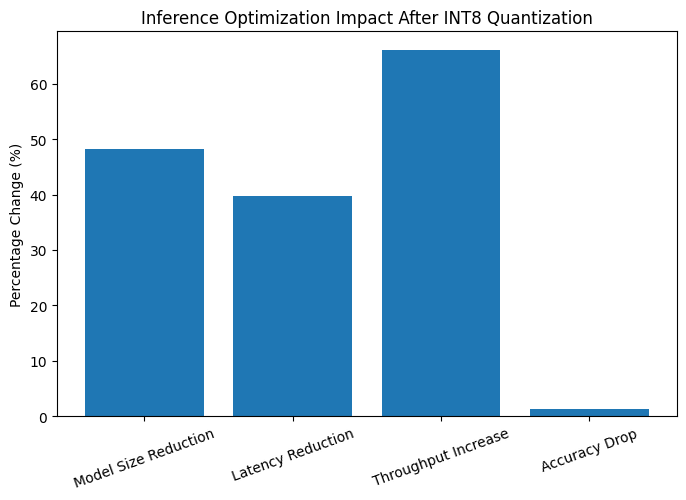

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

optimization_summary = pd.DataFrame({
    "Metric": [
        "Model Size Reduction",
        "Latency Reduction",
        "Throughput Increase",
        "Accuracy Drop"
    ],
    "Change (%)": [
        48.21,
        39.80,
        66.11,
        1.32
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(optimization_summary["Metric"], optimization_summary["Change (%)"])
plt.ylabel("Percentage Change (%)")
plt.title("Inference Optimization Impact After INT8 Quantization")
plt.xticks(rotation=20)
plt.show()

In [22]:
import pandas as pd

batch_sizes = [1, 2, 4, 8, 16, 32]
batch_results = []

for bs in batch_sizes:
    print(f"Evaluating batch size = {bs}")

    fp32_acc, fp32_latency, fp32_throughput = evaluate_model(
        model_fp32,
        tokenizer,
        texts,
        labels,
        batch_size=bs
    )

    int8_acc, int8_latency, int8_throughput = evaluate_model(
        model_int8,
        tokenizer,
        texts,
        labels,
        batch_size=bs
    )

    batch_results.append({
        "Batch Size": bs,
        "Model": "FP32",
        "Accuracy": fp32_acc,
        "Latency per Sample (ms)": fp32_latency,
        "Throughput (samples/sec)": fp32_throughput
    })

    batch_results.append({
        "Batch Size": bs,
        "Model": "INT8",
        "Accuracy": int8_acc,
        "Latency per Sample (ms)": int8_latency,
        "Throughput (samples/sec)": int8_throughput
    })

batch_df = pd.DataFrame(batch_results)
batch_df

Evaluating batch size = 1
Evaluating batch size = 2
Evaluating batch size = 4
Evaluating batch size = 8
Evaluating batch size = 16
Evaluating batch size = 32


,Batch Size,Model,Accuracy,Latency per Sample (ms),Throughput (samples/sec)
0,1,FP32,0.912,133.535416,7.488650
1,1,INT8,0.906,39.051413,25.607268
2,2,FP32,0.912,75.880531,13.178611
3,2,INT8,0.902,46.690040,21.417844
4,4,FP32,0.912,72.455304,13.801612
5,4,INT8,0.898,47.014200,21.270169
6,8,FP32,0.912,71.425231,14.000655
7,8,INT8,0.900,55.074173,18.157331
8,16,FP32,0.912,74.394099,13.441926
9,16,INT8,0.900,51.907972,19.264864


In [23]:
import torch
from torch.profiler import profile, ProfilerActivity

def estimate_flops(model, tokenizer, text, max_length=128):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

    with profile(
        activities=[ProfilerActivity.CPU],
        with_flops=True,
        record_shapes=True
    ) as prof:
        with torch.no_grad():
            model(**inputs)

    total_flops = 0
    for event in prof.key_averages():
        if event.flops is not None:
            total_flops += event.flops

    return total_flops

In [24]:
sample_text = texts[0]

fp32_flops = estimate_flops(model_fp32, tokenizer, sample_text, max_length=128)

print(f"FP32 FLOPs: {fp32_flops:,}")
print(f"FP32 GFLOPs: {fp32_flops / 1e9:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


FP32 FLOPs: 10,874,096,896
FP32 GFLOPs: 10.8741


In [25]:
int8_flops = estimate_flops(model_int8, tokenizer, sample_text, max_length=128)

print(f"INT8 FLOPs: {int8_flops:,}")
print(f"INT8 GFLOPs: {int8_flops / 1e9:.4f}")

INT8 FLOPs: 1,278,208
INT8 GFLOPs: 0.0013
